In [1]:
import matplotlib.pyplot as plt
from os import walk
import json
import numpy as np 
import os

In [3]:
results_01 = '/home/thais/Dev/TVMBench/tmp_logs/autoscheduler/llvm/search_space_1000/cache-results-01'
results_02 = '/home/thais/Dev/TVMBench/tmp_logs/autoscheduler/llvm/search_space_1000/cache-results-02'
results_03 = '/home/thais/Dev/TVMBench/tmp_logs/autoscheduler/llvm/search_space_1000/cache-results-03'
results_04 = '/home/thais/Dev/TVMBench/tmp_logs/autoscheduler/llvm/search_space_1000/cache-results-04'
results_05 = '/home/thais/Dev/TVMBench/tmp_logs/autoscheduler/llvm/search_space_1000/cache-results-05'

def gen_values(mypath):
    id_ = 0
    values = {}
    values_acc = {}
    for (dir_path, dir_names, file_names) in walk(mypath):
        for filename in file_names:
            if("output" not in filename):
                with open(os.path.join(dir_path, filename), 'r') as f:
                    values[id_] = ['', []]
                    values_acc[id_] = ['', []]
                    best = 1000
                    s = 0
                    for l in f:
                        result = json.loads(l)
                        task = result['i'][0][0]
                        values[id_][0] = task
                        values_acc[id_][0] = task
                        r = sum(result['r'][0])/len(result['r'][0])
                        if(r < best):
                            best = r
                        if(best < 1000):
                            values[id_][1].append(best)
                        if(r < 1000):
                            s += r
                        values_acc[id_][1].append(s)
                    id_ += 1
    return values, values_acc

values_01, values_acc_01 = gen_values(results_01)
#values_02, values_acc_02 = gen_values(results_02)
#values_03, values_acc_03 = gen_values(results_03)
#values_04, values_acc_04 = gen_values(results_04)
#values_05, values_acc_05 = gen_values(results_05)

In [9]:
#len(values_01), len(values_02)
len(values_01)

433

In [4]:
def fix_values(values):
    for idx, task in enumerate(values):
        while(len(values[task][1]) < 1000 and len(values[task][1]) >= 800):
            v = values[task][1][len(values[task][1])-1]
            values[task][1].append(v)
    return values
        
values_01 = fix_values(values_01)
#values_02 = fix_values(values_02)

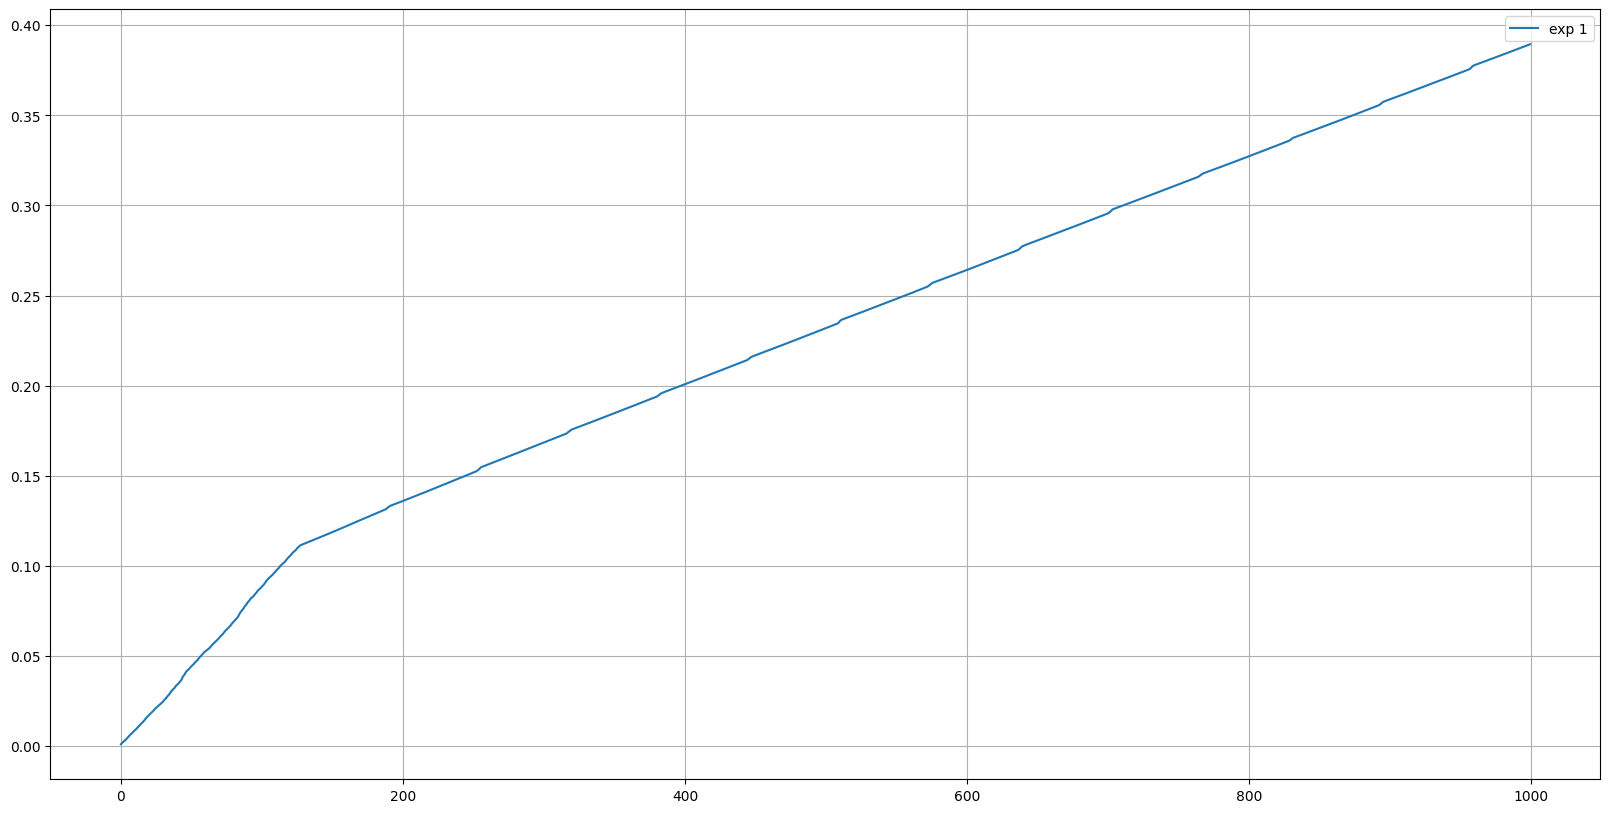

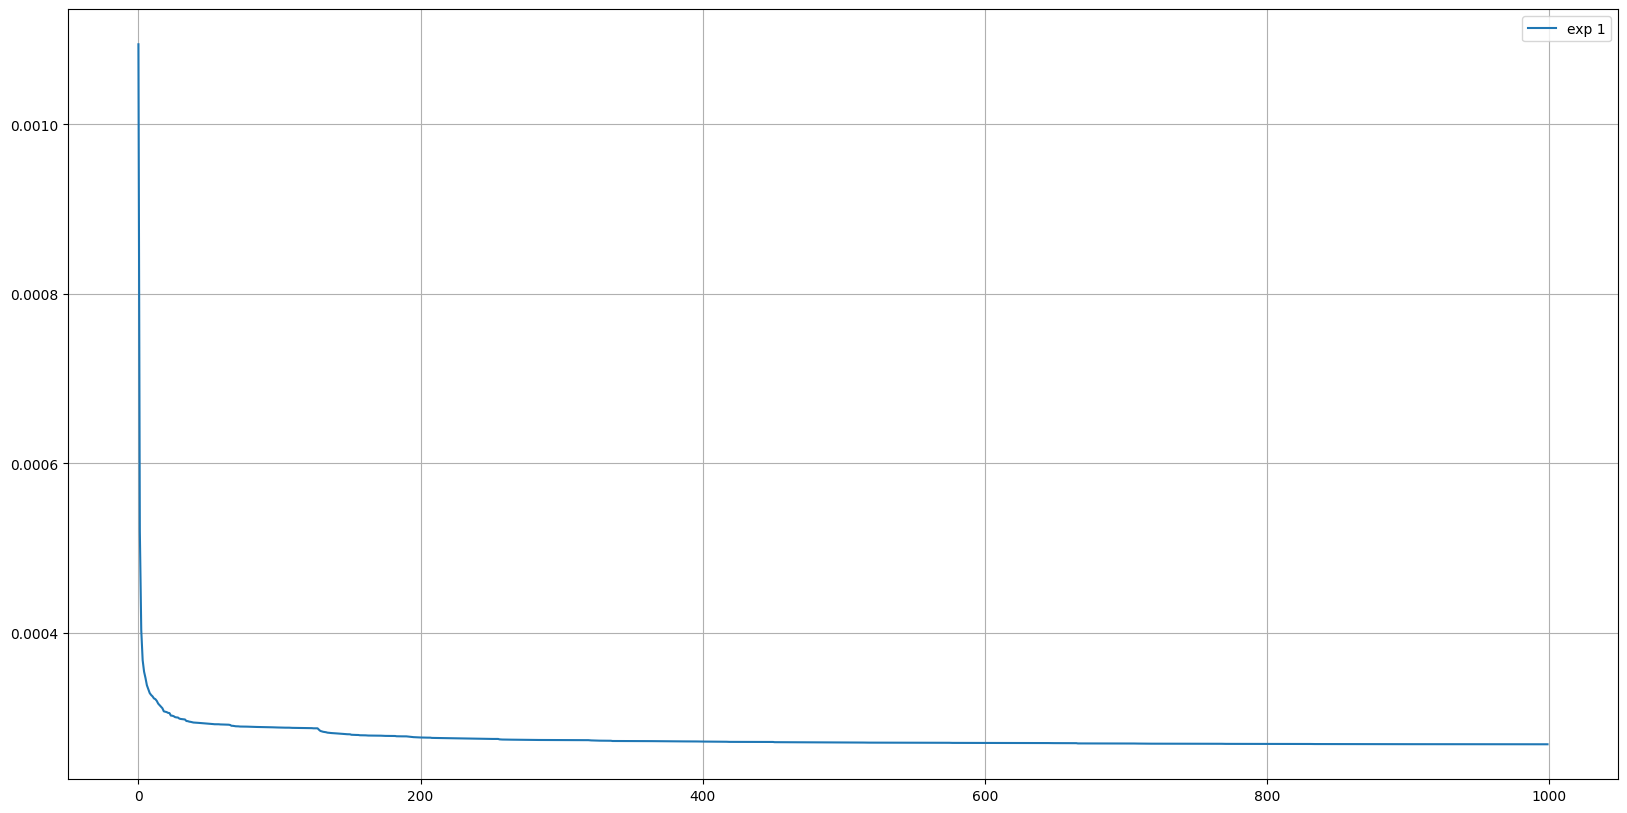

In [8]:
def get_plot_values(values):
    result = np.zeros(1000)
    result_c = np.zeros(1000)

    #for idx, value in enumerate(result_n):
    #    result_n[idx] = result_n[idx] / result_cn[idx]
    #for idx, value in enumerate(result_o):
    #    result_o[idx] = result_o[idx] / result_co[idx]

    for idx, task in enumerate(values):
        if(len(values[task][1]) >= 1000):
            for idx, value in enumerate(values[task][1][:1000]):
                result[idx] += value
                result_c[idx] += 1

    for idx, value in enumerate(result):
        result[idx] = result[idx] / result_c[idx]
    
    return result, result_c

result_01, result_01_c = get_plot_values(values_01)
result_01_acc, result_01_c_acc = get_plot_values(values_acc_01)
#result_02, result_02_c = get_plot_values(values_02)
#result_02_acc, result_02_c_acc = get_plot_values(values_acc_02)
    
plt.figure(figsize=(20, 10))
plt.plot(result_01_acc, label="exp 1")
#plt.plot(result_02_acc, label="exp 2")
plt.grid()
plt.legend()
plt.show()
plt.figure(figsize=(20, 10))
plt.plot(result_01, label="exp 1")
#plt.plot(result_02, label="exp 2")
plt.grid()
plt.legend()
plt.show()